## Company Var Explorer

In this notebook I explore all the variables in the filtered bulk dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)

In [2]:
INPUT_PATH  = "../data/processed/filtered_bb_sme_sectors.csv"
DATE_COLS = [
    "IncorporationDate",
    "Accounts.NextDueDate",
    "Accounts.LastMadeUpDate",
    "ConfStmtNextDueDate",
    "ConfStmtLastMadeUpDate",
] + [f"PreviousName_{i}.CONDATE" for i in range(1, 11)]

In [3]:
# Reading bulk CSV
df = pd.read_csv(INPUT_PATH, low_memory=False)
df.columns = df.columns.str.strip()

for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], dayfirst=True, errors="coerce")

print(f"Loaded {len(df):,} rows, {df.shape[1]} columns")

Loaded 1,372,321 rows, 57 columns


### 0. Dataset overview

In [4]:
df.dtypes

CompanyName                                      str
CompanyNumber                                    str
RegAddress.CareOf                                str
RegAddress.POBox                                 str
RegAddress.AddressLine1                          str
RegAddress.AddressLine2                          str
RegAddress.PostTown                              str
RegAddress.County                                str
RegAddress.Country                               str
RegAddress.PostCode                              str
CompanyCategory                                  str
CompanyStatus                                    str
CountryOfOrigin                                  str
DissolutionDate                              float64
IncorporationDate                     datetime64[us]
Accounts.AccountRefDay                       float64
Accounts.AccountRefMonth                     float64
Accounts.NextDueDate                  datetime64[us]
Accounts.LastMadeUpDate               datetime

In [5]:
null_summary = (
    df.isnull().sum().rename('null_count').to_frame()
)

In [6]:
null_summary['null_pct'] = (null_summary['null_count'] / len(df) * 100).round(1)
null_summary['dtype'] = df.dtypes
null_summary.sort_values('null_pct', ascending=False)

,null_count,null_pct,dtype
DissolutionDate,1372321,100.0,float64
PreviousName_9.CONDATE,1372299,100.0,datetime64[us]
PreviousName_9.CompanyName,1372299,100.0,str
PreviousName_10.CONDATE,1372308,100.0,datetime64[us]
PreviousName_10.CompanyName,1372308,100.0,str
PreviousName_7.CONDATE,1372247,100.0,datetime64[us]
PreviousName_7.CompanyName,1372247,100.0,str
PreviousName_8.CONDATE,1372277,100.0,datetime64[us]
PreviousName_8.CompanyName,1372277,100.0,str
PreviousName_5.CONDATE,1371830,100.0,datetime64[us]


### 1. Identifiers

`CompanyName`, `CompanyNumber` and `URI` are metadata fields and carry no distributional signal. Aside from being unique for each company.

In [7]:
print("Rows:", len(df))
print("Unique CompanyNumbers:", df['CompanyNumber'].nunique())
print("Unique CompanyNames:", df['CompanyName'].nunique())
print("\nSample company numbers:")
print(df['CompanyNumber'].head(10).tolist())
print("\nSample URIs:")
print(df['URI'].head(3).tolist())

Rows: 1372321
Unique CompanyNumbers: 1372321
Unique CompanyNames: 1372319

Sample company numbers:
['16092999', '11743365', '15073164', '13522064', '11006939', '02537158', '01382560', '14502415', '02076454', '09388058']

Sample URIs:
['http://business.data.gov.uk/id/company/16092999', 'http://business.data.gov.uk/id/company/11743365', 'http://business.data.gov.uk/id/company/15073164']


### 2. Company base characterisctics

- `CompanyCategory` = governance structure; for this DB 98% PLC
- `CompanyStatus` = in this DB "Active" only
- `CountryOfOrigin` = country were the company is originally incorporated; for this DB 100% UK

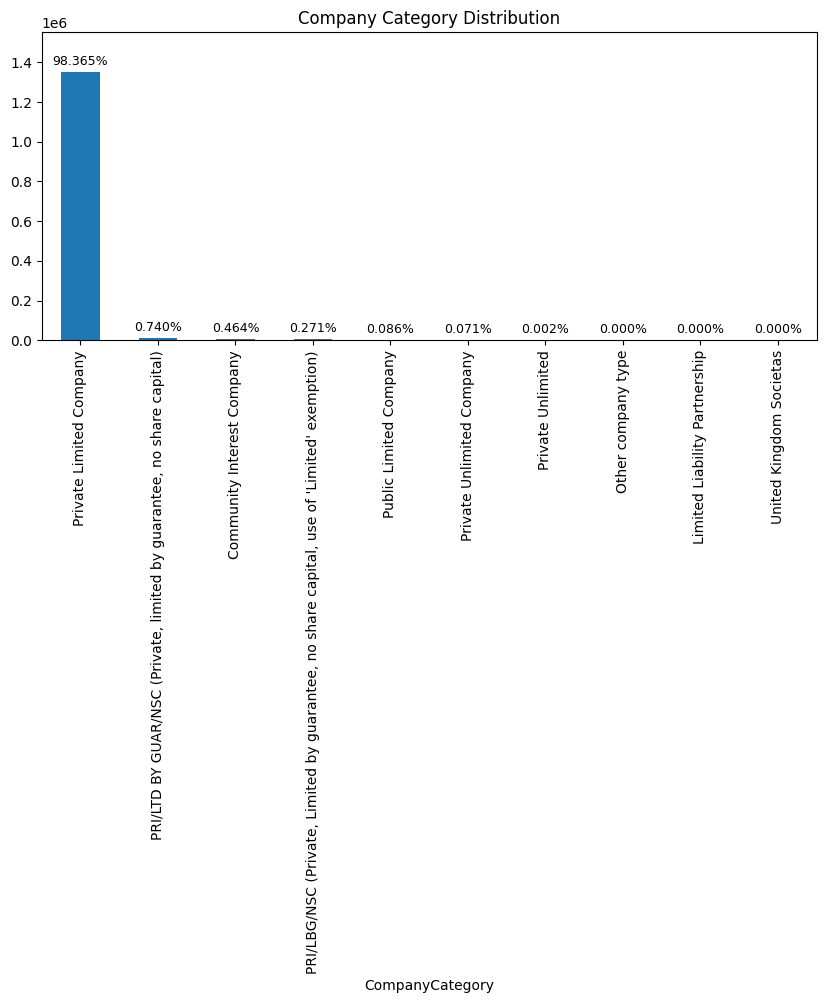

In [8]:
counts = df["CompanyCategory"].value_counts()
total = counts.sum()

ax = counts.plot(kind="bar", figsize=(10, 4), title="Company Category Distribution")

ax.bar_label(
    ax.containers[0],
    # labels=[f"{v:,}" for v in counts], # absolute
    labels=[f"{v/total:.3%}" for v in counts], # percentages
    padding=3, fontsize=9,
)
ax.margins(y=0.15)

In [9]:
df['CountryOfOrigin'].value_counts()

CountryOfOrigin
United Kingdom    1372319
UNITED KINGDOM          1
LUXEMBOURG              1
Name: count, dtype: int64

### 3. Sparse / dropped columns

Variables excluded from detailed analysis — listed with null rate and reason for exclusion.

In [10]:
sparse_cols = {
    'DissolutionDate':                    'Dataset filtered to Active companies only',
    'RegAddress.POBox':                   'UK companies rarely register via PO Box',
    'RegAddress.CareOf':                  'Used only for care-of addresses',
    'Returns.NextDueDate':                'Annual Returns abolished 2016; replaced by Confirmation Statements',
    'Returns.LastMadeUpDate':             'Annual Returns abolished 2016; replaced by Confirmation Statements',
    'PreviousName_5.CONDATE':             'Fewer than 0.04% of companies renamed ≥5 times',
    'PreviousName_5.CompanyName':         'Fewer than 0.04% of companies renamed ≥5 times',
    'PreviousName_6.CONDATE':             'Near-empty',
    'PreviousName_6.CompanyName':         'Near-empty',
    'PreviousName_7.CONDATE':             'Near-empty',
    'PreviousName_7.CompanyName':         'Near-empty',
    'PreviousName_8.CONDATE':             'Near-empty',
    'PreviousName_8.CompanyName':         'Near-empty',
    'PreviousName_9.CONDATE':             'Near-empty',
    'PreviousName_9.CompanyName':         'Near-empty',
    'PreviousName_10.CONDATE':            'Near-empty',
    'PreviousName_10.CompanyName':        'Near-empty',
    'LimitedPartnerships.NumGenPartners': 'All zeros in this filtered set (active Ltd/PLC only)',
    'LimitedPartnerships.NumLimPartners': 'All zeros in this filtered set (active Ltd/PLC only)',
}

rows = []
for col, reason in sparse_cols.items():
    if col in df.columns:
        null_pct = df[col].isna().mean() * 100
        rows.append({'Column': col, 'Null %': f"{null_pct:.1f}%", 'Reason': reason})

pd.DataFrame(rows).set_index('Column')

,Null %,Reason
Column,,
DissolutionDate,100.0%,Dataset filtered to Active companies only
RegAddress.POBox,99.9%,UK companies rarely register via PO Box
RegAddress.CareOf,99.6%,Used only for care-of addresses
Returns.NextDueDate,0.0%,Annual Returns abolished 2016; replaced by Con...
Returns.LastMadeUpDate,68.3%,Annual Returns abolished 2016; replaced by Con...
PreviousName_5.CONDATE,100.0%,Fewer than 0.04% of companies renamed ≥5 times
PreviousName_5.CompanyName,100.0%,Fewer than 0.04% of companies renamed ≥5 times
PreviousName_6.CONDATE,100.0%,Near-empty
PreviousName_6.CompanyName,100.0%,Near-empty


### 4. Geography

`RegAddress.PostCode` (0% null) is the primary geographic field. Postcode area = first 2 characters (e.g. "EC", "SW", "M1"), giving ~120 meaningful UK areas. `RegAddress.PostTown` (0.4% null) confirms city-level distribution. `County` (70.5% null) and `Country` (14.3% null) are not plotted.

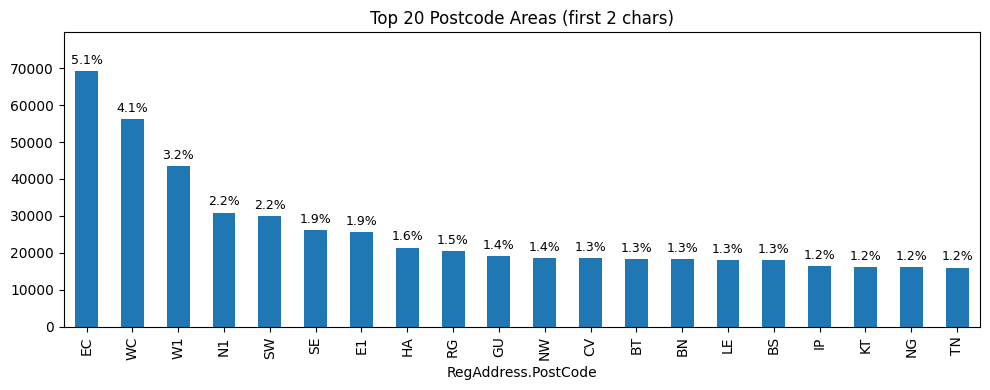

In [11]:
area = df['RegAddress.PostCode'].str[:2].str.upper().str.strip()
area_counts = area.value_counts().head(20)
total = len(df)

ax = area_counts.plot(kind='bar', figsize=(10, 4), title='Top 20 Postcode Areas (first 2 chars)')
ax.bar_label(ax.containers[0], labels=[f"{v/total:.1%}" for v in area_counts], padding=3, fontsize=9)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

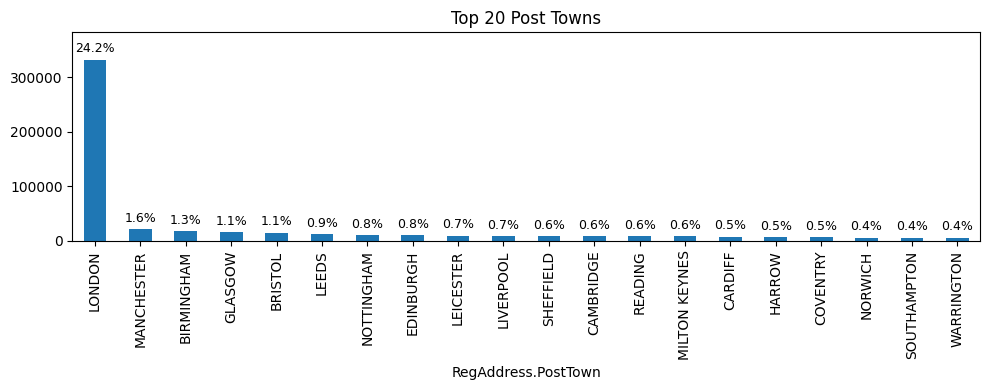

In [12]:
town_counts = df['RegAddress.PostTown'].str.upper().value_counts().head(20)
total = len(df)

ax = town_counts.plot(kind='bar', figsize=(10, 4), title='Top 20 Post Towns')
ax.bar_label(ax.containers[0], labels=[f"{v/total:.1%}" for v in town_counts], padding=3, fontsize=9)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

### 5. Incorporation date

`IncorporationDate` (0% null). `TODAY` pinned to 2026-06-21 for reproducibility (consistent with NB03).

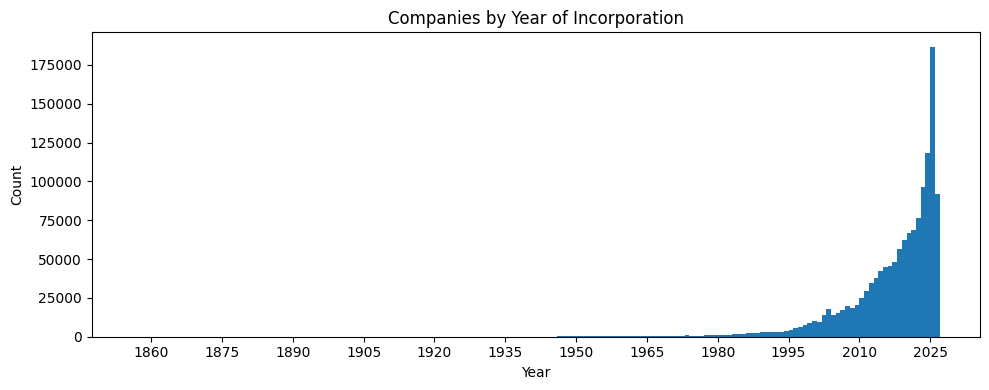

In [13]:
inc_year = df['IncorporationDate'].dt.year.dropna()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(inc_year, bins=range(int(inc_year.min()), int(inc_year.max()) + 2), edgecolor='none')
ax.set_title('Companies by Year of Incorporation')
ax.set_xlabel('Year')
ax.set_ylabel('Count')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True, nbins=15))
plt.tight_layout()
plt.show()

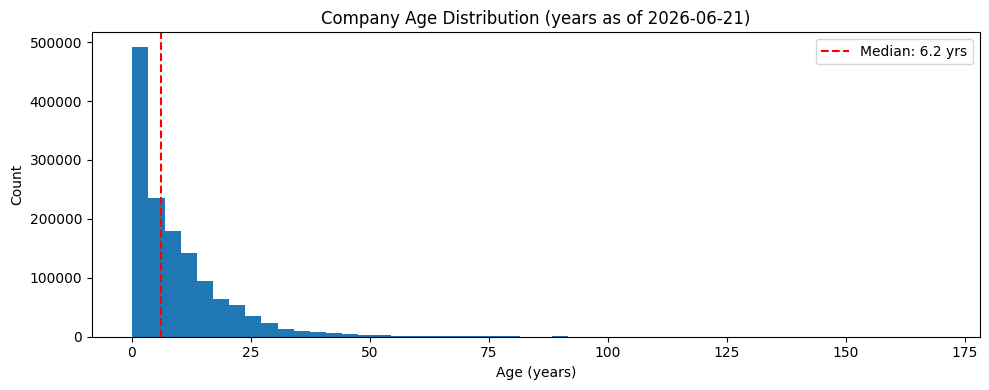

Median: 6.2 yrs  |  Mean: 9.5 yrs  |  Max: 169.7 yrs


In [14]:
TODAY = pd.Timestamp('2026-06-21')
age_years = (TODAY - df['IncorporationDate']).dt.days / 365.25

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(age_years.dropna(), bins=50, edgecolor='none')
ax.axvline(age_years.median(), color='red', linestyle='--', label=f'Median: {age_years.median():.1f} yrs')
ax.set_title('Company Age Distribution (years as of 2026-06-21)')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median: {age_years.median():.1f} yrs  |  Mean: {age_years.mean():.1f} yrs  |  Max: {age_years.max():.1f} yrs")

### 6. Sector & Segment

`sector` and `segment` are derived columns added during NB01 filtering.

- `sector` — mapped from SIC section. Primary SIC (`SicText_1`) used first; `SicText_2–4` are fallback (69.9–92.1% null).
- `segment` — mapped from `Accounts.AccountCategory` → Micro / Small / Medium / Large.

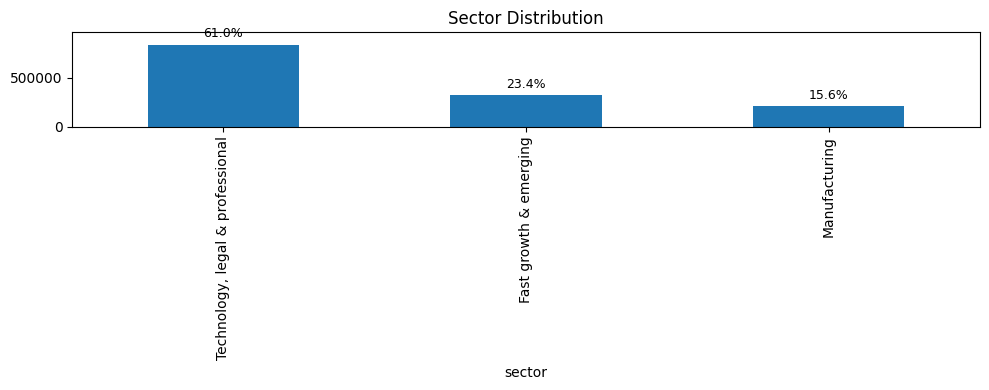

In [16]:
counts = df['sector'].value_counts()
total = counts.sum()

ax = counts.plot(kind='bar', figsize=(10, 4), title='Sector Distribution')
ax.bar_label(ax.containers[0], labels=[f"{v/total:.1%}" for v in counts], padding=3, fontsize=9)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

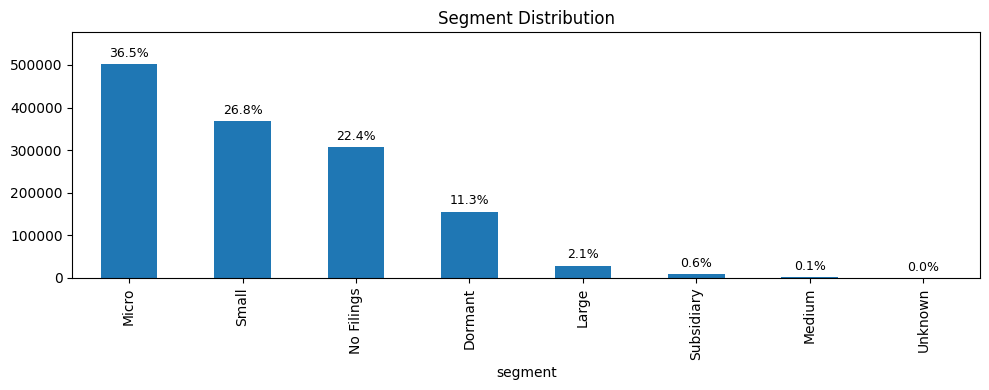

In [17]:
counts = df['segment'].value_counts()
total = counts.sum()

ax = counts.plot(kind='bar', figsize=(10, 4), title='Segment Distribution')
ax.bar_label(ax.containers[0], labels=[f"{v/total:.1%}" for v in counts], padding=3, fontsize=9)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

### 7. Accounts

- `AccountRefMonth` / `AccountRefDay` — fiscal year-end reference date
- `Accounts.LastMadeUpDate` — date accounts were last filed (22.4% null = never filed)
- `Accounts.NextDueDate` — next filing deadline (0.1% null)
- `ConfStmtLastMadeUpDate` — most recent confirmation statement date (16.1% null)
- `Accounts.AccountCategory` — source for `segment`; not plotted separately (see §6)

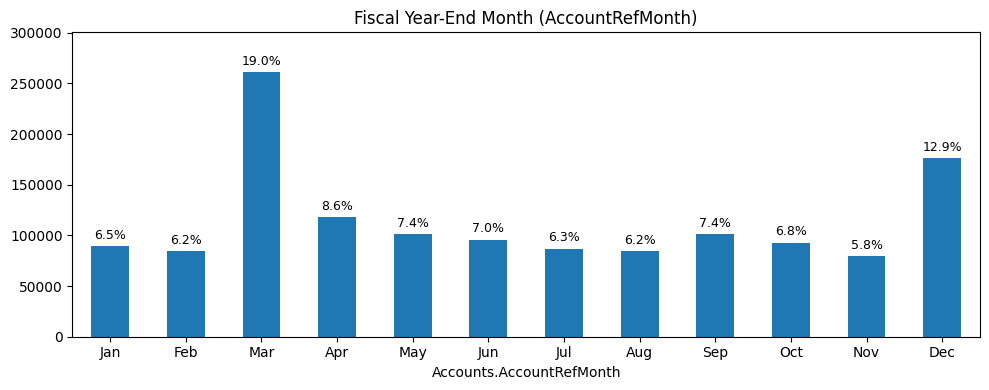

In [18]:
month_counts = df['Accounts.AccountRefMonth'].value_counts().sort_index()
total = month_counts.sum()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

ax = month_counts.plot(kind='bar', figsize=(10, 4), title='Fiscal Year-End Month (AccountRefMonth)')
ax.set_xticklabels(month_labels, rotation=0)
ax.bar_label(ax.containers[0], labels=[f"{v/total:.1%}" for v in month_counts], padding=3, fontsize=9)
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

In [19]:
TODAY = pd.Timestamp('2026-06-21')

print(f"Accounts.LastMadeUpDate null: {df['Accounts.LastMadeUpDate'].isna().mean():.1%}  (companies that have never filed accounts)")

conf_filed = df['ConfStmtLastMadeUpDate'].dropna()
days_since = (TODAY - conf_filed).dt.days
print(f"\nConfStmtLastMadeUpDate:")
print(f"  null: {df['ConfStmtLastMadeUpDate'].isna().mean():.1%}  (never submitted confirmation statement)")
print(f"  median days since last statement: {days_since.median():.0f}")
print(f"  75th pct: {days_since.quantile(0.75):.0f} days")

Accounts.LastMadeUpDate null: 22.4%  (companies that have never filed accounts)

ConfStmtLastMadeUpDate:
  null: 16.1%  (never submitted confirmation statement)
  median days since last statement: 215
  75th pct: 308 days


### 8. Mortgages

Four integer fields tracking charge history. All zero-inflated. `debt_ratio` in NB03 = `NumMortOutstanding / NumMortCharges.clip(1)`.

| Field | Meaning |
|---|---|
| `NumMortCharges` | Total charges ever registered |
| `NumMortOutstanding` | Currently active charges |
| `NumMortPartSatisfied` | Partially repaid |
| `NumMortSatisfied` | Fully repaid |

In [20]:
mort_cols = ['Mortgages.NumMortCharges', 'Mortgages.NumMortOutstanding',
             'Mortgages.NumMortPartSatisfied', 'Mortgages.NumMortSatisfied']
stats = df[mort_cols].describe().T[['mean', '50%', 'max']].rename(columns={'50%': 'median'})
stats['% > 0'] = (df[mort_cols] > 0).mean().mul(100).round(1).values
stats.index = [c.replace('Mortgages.', '') for c in stats.index]
stats.round(2)

,mean,median,max,% > 0
NumMortCharges,0.34,0.0,1448.0,9.4
NumMortOutstanding,0.14,0.0,1229.0,6.7
NumMortPartSatisfied,0.00,0.0,18.0,0.0
NumMortSatisfied,0.20,0.0,1072.0,5.4


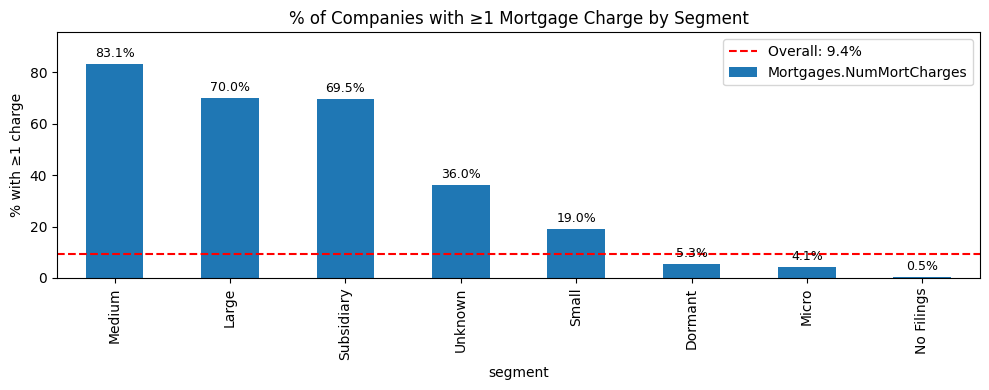

In [21]:
charge_by_seg = (
    df.groupby('segment')['Mortgages.NumMortCharges']
    .apply(lambda x: (x > 0).mean() * 100)
    .sort_values(ascending=False)
)
overall = (df['Mortgages.NumMortCharges'] > 0).mean() * 100

ax = charge_by_seg.plot(kind='bar', figsize=(10, 4), title='% of Companies with ≥1 Mortgage Charge by Segment')
ax.axhline(overall, color='red', linestyle='--', label=f'Overall: {overall:.1f}%')
ax.bar_label(ax.containers[0], labels=[f"{v:.1f}%" for v in charge_by_seg], padding=3, fontsize=9)
ax.set_ylabel('% with ≥1 charge')
ax.margins(y=0.15)
ax.legend()
plt.tight_layout()
plt.show()

### 9. Previous names

`PreviousName_1` through `_4` capture historical names with change dates. Slots 5–10 are near-empty (see §3). Rebranding history is detectable via `PreviousName_1.CompanyName`.

In [22]:
has_prev = df['PreviousName_1.CompanyName'].notna()
print(f"Companies with ≥1 previous name: {has_prev.sum():,} ({has_prev.mean()*100:.1f}%)")
print(f"Companies with ≥2 previous names: {df['PreviousName_2.CompanyName'].notna().sum():,} ({df['PreviousName_2.CompanyName'].notna().mean()*100:.1f}%)")
print(f"Companies with ≥3 previous names: {df['PreviousName_3.CompanyName'].notna().sum():,} ({df['PreviousName_3.CompanyName'].notna().mean()*100:.1f}%)")

Companies with ≥1 previous name: 149,218 (10.9%)
Companies with ≥2 previous names: 26,990 (2.0%)
Companies with ≥3 previous names: 5,960 (0.4%)
